#OBERALP RETAIL DATA EXPLORATION AND CLV CALCULATION

Necessary libraries are downloaded to Colab system.

In [ ]:
!pip install lifetimes
!pip install squarify

Necessary libraries are imported

In [ ]:
import pandas as pd
from google.colab import files
from lifetimes import BetaGeoFitter, GammaGammaFitter #for model fitting
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data #for data summarization and calibration
import numpy as np
#special libraries for lifetimes plotting
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix, plot_period_transactions, plot_calibration_purchases_vs_holdout_purchases #special libraries for lifetimes plotting

import matplotlib.pyplot as plt
import squarify #for visualization
from itertools import combinations #combining itemsets
import seaborn as sns

Importing the file and reading the first 5 rows

In [ ]:
retail = pd.read_parquet('/content/retail_20250114_2.parquet')

In [ ]:
retail.head(5)

,DATE,TIME,STOREID,CODEARTICLE,EANCODE,RECEIPTNUMBER,QUANTITY,CBRID,CURRENCYID,TOTALTAXINCLUDED,ISGENERICCUSTOMER,OBERALPID
0,2024-11-30,15:31:30,AT01,00-0000025858,4053865477766,24003348,1,RAT0100132257,EUR,40.000,0,None
1,2024-11-30,15:28:14,AT01,00-0000028358,4053866446242,24003347,-1,RAT0100132257,EUR,-168.000,0,None
2,2024-11-30,15:28:14,AT01,00-0000028455,4053866573085,24003347,1,RAT0100132257,EUR,311.430,0,None
3,2024-11-30,15:28:14,AT01,00-0000028774,4053866585965,24003347,1,RAT0100132257,EUR,28.810,0,None
4,2024-11-30,15:28:14,AT01,00-0000028644,4053866539968,24003347,1,RAT0100132257,EUR,23.360,0,None


Initial data exploration steps

In [ ]:
retail.columns

Index(['DATE', 'TIME', 'STOREID', 'CODEARTICLE', 'EANCODE', 'RECEIPTNUMBER',
       'QUANTITY', 'CBRID', 'CURRENCYID', 'TOTALTAXINCLUDED',
       'ISGENERICCUSTOMER', 'OBERALPID'],
      dtype='object')

In [ ]:
# Ensure no NaN values in 'CODEARTICLE' before applying .str.startswith()
retail_df = retail[retail['CODEARTICLE'].fillna('').str.startswith("00-")].reset_index(drop=True)

# Display the filtered DataFrame structure to confirm
retail_df.head()


,DATE,TIME,STOREID,CODEARTICLE,EANCODE,RECEIPTNUMBER,QUANTITY,CBRID,CURRENCYID,TOTALTAXINCLUDED,ISGENERICCUSTOMER,OBERALPID
0,2024-11-30,15:31:30,AT01,00-0000025858,4053865477766,24003348,1,RAT0100132257,EUR,40.000,0,None
1,2024-11-30,15:28:14,AT01,00-0000028358,4053866446242,24003347,-1,RAT0100132257,EUR,-168.000,0,None
2,2024-11-30,15:28:14,AT01,00-0000028455,4053866573085,24003347,1,RAT0100132257,EUR,311.430,0,None
3,2024-11-30,15:28:14,AT01,00-0000028774,4053866585965,24003347,1,RAT0100132257,EUR,28.810,0,None
4,2024-11-30,15:28:14,AT01,00-0000028644,4053866539968,24003347,1,RAT0100132257,EUR,23.360,0,None


In [ ]:
retail_df.shape

(1307068, 12)

In [ ]:
retail_df.dtypes

,0
DATE,object
TIME,object
STOREID,object
CODEARTICLE,object
EANCODE,object
RECEIPTNUMBER,int64
QUANTITY,int32
CBRID,object
CURRENCYID,object
TOTALTAXINCLUDED,object


In [ ]:
retail_df.isnull().sum()

,0
DATE,0
TIME,0
STOREID,0
CODEARTICLE,0
EANCODE,0
RECEIPTNUMBER,0
QUANTITY,0
CBRID,0
CURRENCYID,0
TOTALTAXINCLUDED,0


Our first aim is to find top 20 customers based on revenue

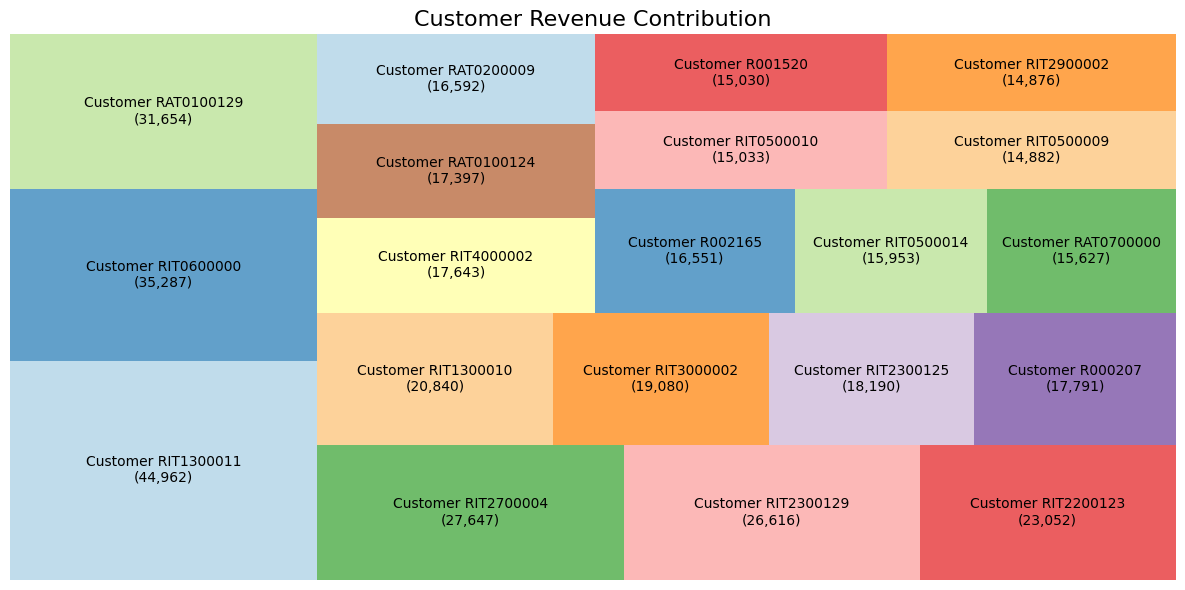

In [ ]:
# Calculate total revenue for each customer
customer_revenue = retail_df.groupby('CBRID')['TOTALTAXINCLUDED'].sum().reset_index()

# Filter out customers with 0 revenue
customer_revenue = customer_revenue[customer_revenue['TOTALTAXINCLUDED'] > 0]

# Convert 'TOTALTAXINCLUDED' to float type
customer_revenue['TOTALTAXINCLUDED'] = customer_revenue['TOTALTAXINCLUDED'].astype(float)

# Sort by revenue and create labels
customer_revenue_sorted = customer_revenue.sort_values(by='TOTALTAXINCLUDED', ascending=False).head(20)  # Limit to top 20 customers for clarity

# Adjust the label to fit in the boxes
labels = [
    f'Customer {x[:10]}\n({y:,.0f})'  # Take only the first 10 characters of the customer number
    for x, y in zip(customer_revenue_sorted['CBRID'], customer_revenue_sorted['TOTALTAXINCLUDED'])
]

# Plotting the treemap
plt.figure(figsize=(12, 6))
squarify.plot(
    sizes=customer_revenue_sorted['TOTALTAXINCLUDED'],
    label=labels,
    color=plt.cm.Paired.colors[:len(customer_revenue_sorted)],
    alpha=0.7
)

# Title and label adjustments
plt.title('Customer Revenue Contribution', fontsize=16)
plt.axis('off')
plt.tight_layout()

# Show the plot
plt.show()


### Association Rule Mining for Retail Data

Association rule mining is a powerful technique used to identify relationships between products frequently purchased together.

#### Example Insights:
- Customers buying trekking boots often purchase waterproof jackets.
- Backpacks are frequently bought with hiking poles.

These findings help Salewa:
- Design product bundles (e.g., boots + socks).
- Optimize store layouts by placing related products together.
- Enhance online recommendations (e.g., "Customers also bought...").

Association rule mining provides actionable data to improve customer experience and boost sales.



Top 10 Product Pairs Bought Together:
                     Product Pair  Count
0  (00-0000027258, 00-0000027257)   6275
1  (00-0000027257, 00-0000027258)   6125
2  (00-0000027836, 00-0000027835)   5850
3  (00-0000024812, 00-0000027257)   4919
4  (00-0000027257, 00-0000024812)   3475
5  (00-0000027835, 00-0000027257)   3225
6  (00-0000027257, 00-0000027835)   3110
7  (00-0000026982, 00-0000026981)   2995
8  (00-0000024812, 00-0000026981)   2905
9  (00-0000026537, 00-0000026538)   2857


<Figure size 1200x800 with 0 Axes>

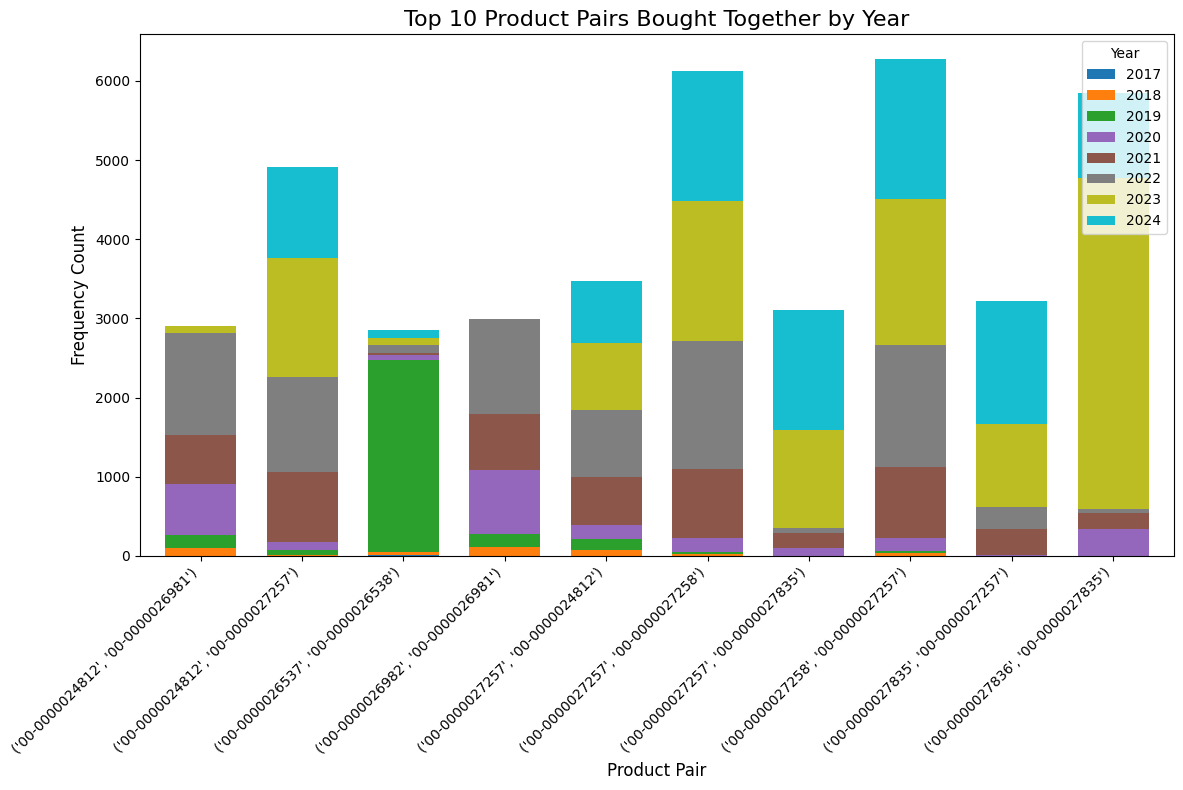

In [ ]:
# Step 1: Group products by 'RECEIPTNUMBER' and create unique product pairs
retail_df['year'] = pd.to_datetime(retail_df['DATE']).dt.year
product_pairs = retail_df.groupby(['RECEIPTNUMBER', 'year'])['CODEARTICLE'].apply(
    lambda products: [pair for pair in combinations(products, 2) if pair[0] != pair[1]] if len(products) > 1 else []
).explode()

# Step 2: Count the frequency of each unique pair per year
pair_counts_by_year = product_pairs.groupby([product_pairs, product_pairs.index.get_level_values('year')]).size()
pair_counts_df = pair_counts_by_year.reset_index(name='Count')
pair_counts_df.columns = ['Product Pair', 'Year', 'Count']

# Step 3: Aggregate to find the total counts for all years and select the top 10 pairs
top_pairs = (
    pair_counts_df.groupby('Product Pair')['Count'].sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
top_pairs_df = pair_counts_df[pair_counts_df['Product Pair'].isin(top_pairs)]

# Pivot to create a matrix for plotting
plot_data = top_pairs_df.pivot(index='Product Pair', columns='Year', values='Count').fillna(0)

# --- Table Output ---
print("\nTop 10 Product Pairs Bought Together:")
print(top_pairs_df.groupby('Product Pair')['Count'].sum().sort_values(ascending=False).reset_index())

# Plotting the Stacked Bar Chart
plt.figure(figsize=(12, 8))
plot_data.plot(kind='bar', stacked=True, colormap='tab10', figsize=(12, 8), width=0.7)

# Properly synchronize x-axis labels
plt.xticks(
    ticks=range(len(plot_data.index)),
    labels=plot_data.index.astype(str),
    rotation=45,
    ha='right',
    fontsize=10,
)
plt.title('Top 10 Product Pairs Bought Together by Year', fontsize=16)
plt.xlabel('Product Pair', fontsize=12)
plt.ylabel('Frequency Count', fontsize=12)
plt.legend(title='Year', fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()


- **1st pair**: Since 2020, this pair has been purchased together consistently, reaching its peak in 2022. However, it saw a significant decline in 2023 and was not purchased together at all in 2024.
- **2nd pair**: Starting from 2021, this pair has continued to be purchased together. Although there was a slight decline in the last year, it remains in demand.
- **3rd pair**: This pair was purchased together consistently between 2021 and 2023.
- **4th pair**: This pair began increasing in demand in 2021 and has been purchased together regularly since then.
- **5th pair**: Since 2022, this pair has been one of the most frequently purchased combinations.
- **6th pair**: Although this pair was purchased together less frequently in earlier years, it has shown a significant upward trend starting in 2023.
- **7th pair**: This pair began gaining popularity in 2023 and has been purchased consistently since then.
- **9th pair**: This pair experienced its highest purchase volume in 2023. While demand slightly decreased in 2024, it remains a popular combination.
- **10th pair**: This pair had high demand in 2022 but has gradually declined in subsequent years.

### Customer Loyalty Cohort Analysis

Customer loyalty cohort analysis is a method used to track and analyze the behavior of customer groups (or cohorts) over time. A cohort refers to a group of customers who share a common characteristic, typically based on their purchase date or first purchase period. By observing these cohorts, businesses can gain insights into customer retention, engagement, and loyalty trends.

#### Why Use Cohort Analysis?
Cohort analysis helps businesses understand customer behavior patterns, enabling them to:
- Identify retention trends: By analyzing how long customers continue to engage or make purchases after their initial interaction, businesses can evaluate their retention rates.
- Evaluate marketing effectiveness: By observing cohorts over time, companies can assess the impact of marketing campaigns on customer loyalty.
- Improve customer segmentation: By studying the performance of different cohorts, businesses can identify which customer segments are more loyal or profitable.

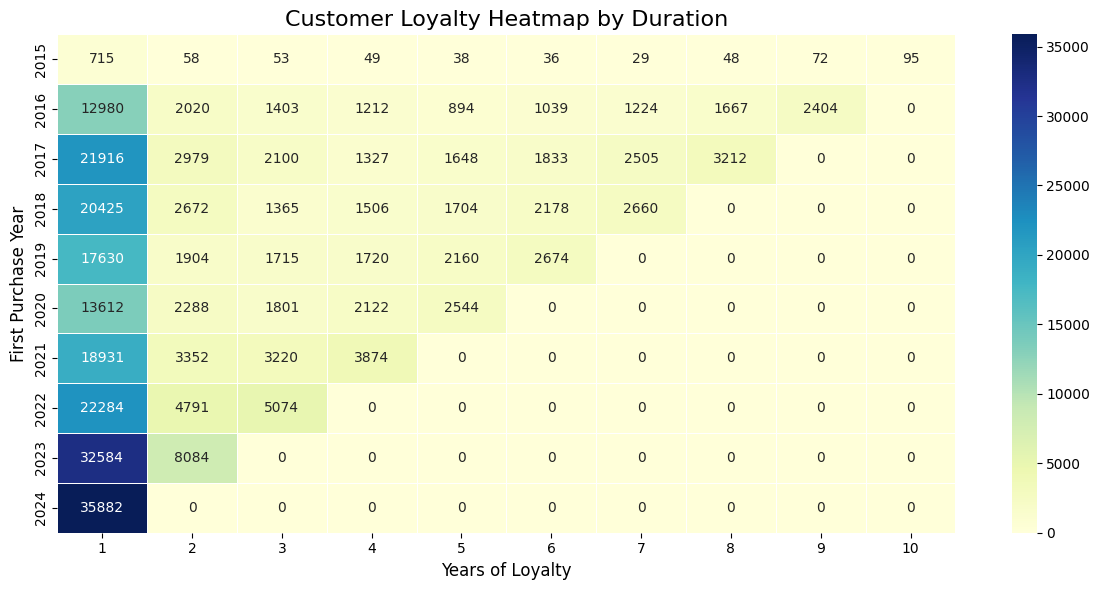

In [ ]:
# Step 1: Extract the year from the 'DATE' column
retail_df['year'] = pd.to_datetime(retail_df['DATE']).dt.year

# Step 2: Determine the first and last purchase year for each customer
retail_df['first_purchase_year'] = retail_df.groupby('CBRID')['year'].transform('min')
retail_df['last_purchase_year'] = retail_df.groupby('CBRID')['year'].transform('max')

# Step 3: Calculate loyalty duration for each customer
retail_df['years_loyalty'] = retail_df['last_purchase_year'] - retail_df['first_purchase_year'] + 1

# Step 4: Group by loyalty duration and visualize as a heatmap
loyalty_heatmap_data = (
    retail_df.groupby(['first_purchase_year', 'years_loyalty'])['CBRID']
    .nunique()  # Count unique customers
    .unstack(fill_value=0)  # Pivot for heatmap
)

# Step 5: Plotting the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(loyalty_heatmap_data, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title('Customer Loyalty Heatmap by Duration', fontsize=16)
plt.xlabel('Years of Loyalty', fontsize=12)
plt.ylabel('First Purchase Year', fontsize=12)
plt.tight_layout()
plt.show()


### Business Implications for Customer Loyalty Heatmap

1. **Focus on Retention Beyond Year 2:**  
   The heatmap shows a significant drop in customer loyalty after the second year for most cohorts. Implement retention strategies (e.g., loyalty programs, personalized offers) to keep customers engaged beyond this point.

2. **Analyze Long-Term Loyalty Factors:**  
   Older cohorts (e.g., 2017–2020) show a gradual decline in retention over time. Investigate factors that cause disengagement, such as changes in product offerings, pricing, or competition, to improve long-term customer loyalty.

3. **Capitalize on Recent Growth:**  
   The larger size of recent cohorts (2022–2024) presents an opportunity for growth. Focus on nurturing these new customers with targeted campaigns to ensure they convert into long-term loyal customers.

4. **Monitor 2024 Cohort Trends:**  
   The 2024 cohort shows the largest single-year contribution in Year 1. As this cohort matures, monitor their loyalty patterns closely to assess the effectiveness of current acquisition and engagement strategies.

5. **Prioritize Early Retention Efforts:**  
   Most loyalty is concentrated in the first 1–2 years. Focus resources on enhancing the onboarding experience, offering incentives for repeat purchases, and fostering engagement during this critical period.

6. **Tailor Strategies for Different Cohorts:**  
   Each cohort exhibits unique retention trends. Use these insights to segment customers and design cohort-specific strategies that address their distinct needs and behaviors.


###Annual sales performance for each year

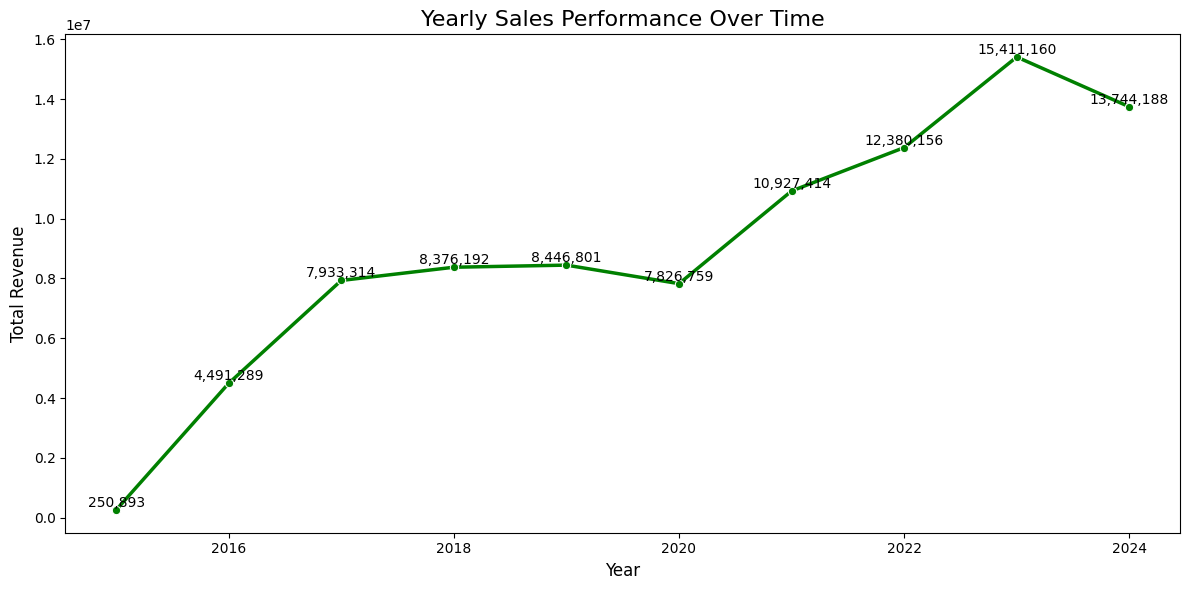

In [ ]:
# Step 1: Extract year from 'DATE' column (assuming your column for date is 'DATE')
retail_df['year'] = pd.to_datetime(retail_df['DATE']).dt.year

# Step 2: Group by year and sum the revenue (using 'TOTALTAXINCLUDED' as revenue column)
yearly_sales = retail_df.groupby('year')['TOTALTAXINCLUDED'].sum().reset_index()

# Step 3: Plotting yearly sales performance
plt.figure(figsize=(12, 6))
ax = sns.lineplot(x='year', y='TOTALTAXINCLUDED', data=yearly_sales, marker='o', color='green', linewidth=2.5)

# Add title and labels
plt.title('Yearly Sales Performance Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Annotate each point on the line plot
for i in range(len(yearly_sales)):
    ax.text(yearly_sales['year'].iloc[i], yearly_sales['TOTALTAXINCLUDED'].iloc[i],
            f'{yearly_sales["TOTALTAXINCLUDED"].iloc[i]:,.0f}',
            horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='black')

# Show the plot
plt.tight_layout()
plt.show()


By looking at the graph above, we can say that annual sales are increasing regularly.

### RFM Calculation

In this section, we prepare the Salewa retail dataset and calculate RFM (Recency, Frequency, Monetary) values for customer segmentation.


 **RFM Calculation:**
   - Used the `summary_data_from_transaction_data` function to calculate RFM values:
     - **Recency:** How recently a customer made a purchase.
     - **Frequency:** How often a customer made purchases.
     - **Monetary:** Total spending of a customer.
   - Set the observation period to the last available date in the dataset.
   - Aggregated transactions weekly (`freq='W'`).

The resulting `rfm_summary` provides insights into customer behavior, which can be used for targeted marketing and customer retention strategies.


In [ ]:
# Convert TIME and TOTALTAXINCLUDED to appropriate types
retail_df['TIME'] = pd.to_datetime(retail_df['TIME'], errors='coerce')
retail_df['TOTALTAXINCLUDED'] = pd.to_numeric(retail_df['TOTALTAXINCLUDED'], errors='coerce')

# Clean the data
retail_df = retail_df[retail_df['TOTALTAXINCLUDED'] > 0]

# Convert DATE to datetime if not already
retail_df['DATE'] = pd.to_datetime(retail_df['DATE'])

# Calculate RFM values
rfm_summary = summary_data_from_transaction_data(
    retail_df,
    customer_id_col='CBRID',
    datetime_col='DATE',
    monetary_value_col='TOTALTAXINCLUDED',
    observation_period_end=retail_df['DATE'].max(),
    freq='W'  # Frequency in weeks
)

print(rfm_summary.head())


         frequency  recency      T  monetary_value
CBRID                                             
0000001        1.0     48.0  364.0            50.0
123            0.0      0.0  445.0             0.0
DE0107         0.0      0.0  130.0             0.0
GOLLING        0.0      0.0   15.0             0.0
R000001        2.0     22.0  498.0            19.0


### Model Initialization and Fitting

In this section, we initialize and fit the **Beta-Geometric/Negative Binomial Distribution (BG/NBD)** model to predict customer purchase behavior.

1. **Model Initialization:**
   - Initialized the `BetaGeoFitter` model with a penalizer coefficient of `0.01` to prevent overfitting.


2. **Model Summary:**
   - Displayed the model parameters and fit summary, which describe customer purchasing patterns and help evaluate the model's performance for future purchase predictions.


In [ ]:
# Initialize the model
bgf = BetaGeoFitter(penalizer_coef=0.01)

# Fit the model
bgf.fit(rfm_summary['frequency'], rfm_summary['recency'], rfm_summary['T'])

# Summarize the model fit
print(bgf)
print(bgf.summary)

<lifetimes.BetaGeoFitter: fitted with 284312 subjects, a: 0.35, alpha: 19.29, b: 0.67, r: 0.24>
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.242920  0.001151         0.240665         0.245176
alpha  19.288830  0.164609        18.966197        19.611463
a       0.351445  0.003369         0.344842         0.358047
b       0.666845  0.006841         0.653437         0.680253


### Frequency-Recency Matrix Plot

In this section, we use the `plot_frequency_recency_matrix` function from the Lifetimes library to visualize customer purchasing behavior based on the **Beta-Geometric/Negative Binomial Distribution (BG/NBD)** model.

1. **Purpose of the Plot:**
   - The matrix provides a visual representation of the relationship between **recency** (how recently a customer purchased) and **frequency** (how often they have purchased).

2. **Actionable Use:**
   - Use this matrix to segment customers and tailor marketing strategies to improve retention and increase sales.


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

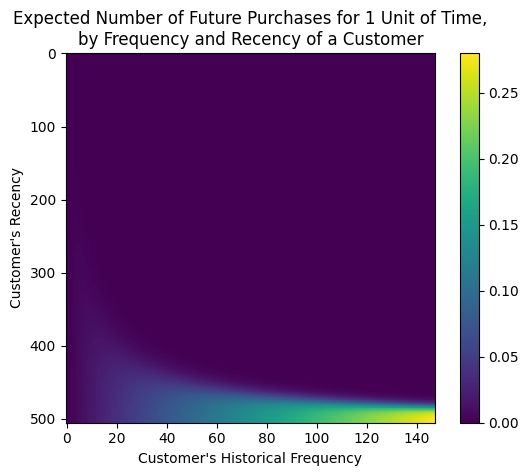

In [ ]:
plot_frequency_recency_matrix(bgf)

### Probability Alive Matrix Plot

In this section, we use the **Probability Alive Matrix** to visualize the likelihood that a customer is still active, based on their purchase behavior.

1. **Purpose of the Plot:**
   - The matrix illustrates the probability that a customer is "alive" (i.e., likely to make another purchase) based on their **recency** (how recently they purchased) and **frequency** (how often they have purchased).

2. **Actionable Use:**
   - This matrix supports strategic decisions by highlighting which customer segments are most likely to contribute to future revenue and which require intervention to maintain engagement.


<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

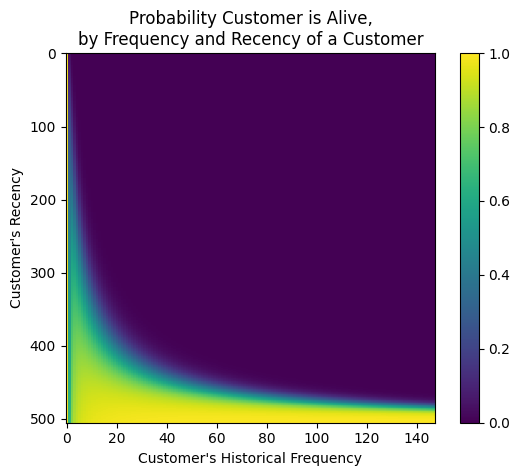

In [ ]:
plot_probability_alive_matrix(bgf)

### Predicting Future Purchases

In this section, we use the **BG/NBD model** to predict the expected number of purchases for each customer in the next time period (e.g., 1 week).

1. **Prediction Process:**
   - Used the `conditional_expected_number_of_purchases_up_to_time` method to calculate the expected purchases for `t=1` (next week) based on each customer's historical data:

2. **Identifying Top Customers:**
   - Customers were ranked based on their predicted purchase counts, highlighting those expected to contribute the most to future sales.

3. **Business Use for Salewa:**
   - These predictions help Salewa focus on high-potential customers for personalized marketing and retention strategies.
   - Target top customers with tailored promotions, exclusive offers, or loyalty rewards to maximize engagement and revenue.


In [ ]:
# Check if 'bgf' has been fitted with your RFM data
if 'bgf' in locals():
    # Calculate expected purchases for the next period (t = 1 week)
    rfm_summary['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        1,  # t = 1, predicting for the next week
        rfm_summary['frequency'],
        rfm_summary['recency'],
        rfm_summary['T']
    )

    # Sort customers by predicted purchases, descending order
    top_customers = rfm_summary.sort_values(by='predicted_purchases', ascending=False).head(5)

    print("Top 5 customers expected to make the most purchases in the next period:")
    print(top_customers[['predicted_purchases']])
else:
    print("The BG/NBD model (bgf) is not fitted yet. Please fit the model first.")


Top 5 customers expected to make the most purchases in the next period:
               predicted_purchases
CBRID                             
RIT3400002022             0.407381
RIT1500022970             0.378572
RIT2300129574             0.326716
RAT0100129450             0.311179
RIT2900002235             0.296031


### Period Transactions Plot

In this section, we use the `plot_period_transactions` function from the Lifetimes library to evaluate how well the **BG/NBD model** fits the actual transaction data.

1. **Purpose of the Plot:**
   - This plot compares the **actual transaction counts** (observed data) with the **predicted transaction counts** (model estimates) across different frequency bins.

2. **Salewa Retail Business Insights:**
   - The plot helps Salewa understand the accuracy of the model in predicting customer purchasing behavior.
   - A good fit indicates that the model reliably estimates transaction frequency, which can be used confidently for forecasting and segmentation.

3. **Actionable Use:**
   - If the model fits well, it can be used to predict future transactions and develop strategies to engage frequent buyers or re-engage customers with declining activity.
   - If the fit is poor, model parameters or input data should be revisited to improve predictions.


<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

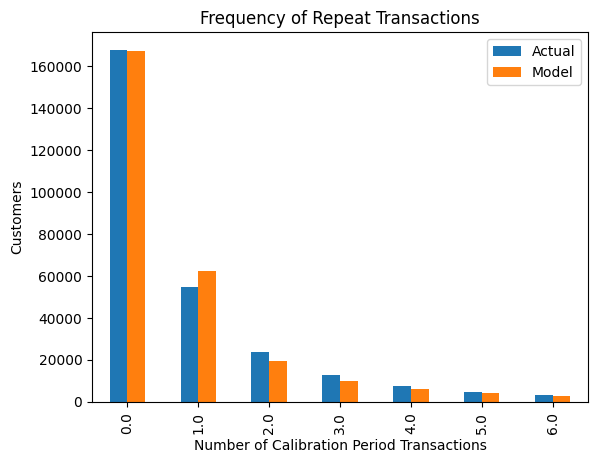

In [ ]:
plot_period_transactions(bgf)

It can be clearly seen that the model is fitted very well according to the graph. Similar result about the model can be seen on 'Holdout period purchases comparison' graph below at the same time.

<Axes: title={'center': 'Actual Purchases in Holdout Period vs Predicted Purchases'}, xlabel='Purchases in calibration period', ylabel='Average of Purchases in Holdout Period'>

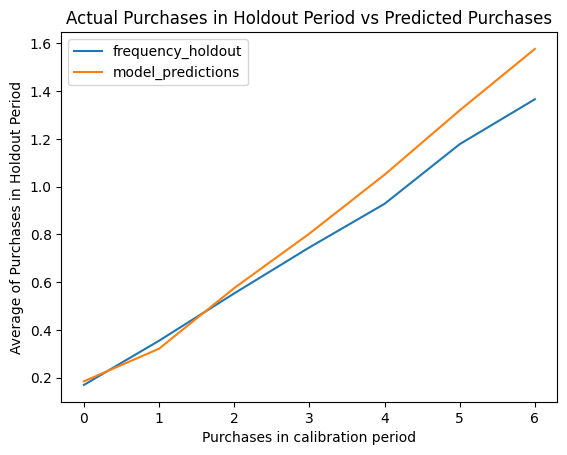

In [ ]:
# Calculate the calibration end date as the 70th percentile of the DATE column
calibration_end_date = retail_df['DATE'].quantile(0.7)

# Create the calibration and holdout data
calibration_holdout = calibration_and_holdout_data(
    retail_df,
    customer_id_col='CBRID',
    datetime_col='DATE',
    calibration_period_end=calibration_end_date,  # Use the actual calculated date here
    observation_period_end=retail_df['DATE'].max()
)

# Fit the BG/NBD model to the calibration data
bgf = BetaGeoFitter()
bgf.fit(calibration_holdout['frequency_cal'], calibration_holdout['recency_cal'], calibration_holdout['T_cal'])

# Plot the calibration vs holdout comparison
plot_calibration_purchases_vs_holdout_purchases(bgf, calibration_holdout)


In [ ]:
# !pip show lifetimes
# !pip install --upgrade lifetimes
# we use these libraries because we are facing some issue of library mismatch

In [ ]:
t = 10 #predict purchases in 10 periods
individual = rfm_summary.iloc[20]
# The below function is an alias to `bfg.conditional_expected_number_of_purchases_up_to_time`
bgf.predict(t, individual['frequency'], individual['recency'], individual['T'])

0.011440141849541695

### Predicting Future Purchases for an Individual Customer

In this section, we use the **BG/NBD model** to predict the number of purchases a specific customer is expected to make over the next 10 periods.

1. **Process:**
   - Selected an individual customer from the `rfm_summary` dataset.
   - Used the `predict` method of the BG/NBD model to estimate future purchases:
     - **t = 10:** Predicting purchases over the next 10 time periods.
     
2. **Purpose for Salewa Retail:**
   - This prediction allows Salewa to evaluate individual customer potential and prioritize engagement strategies for high-value customers.

3. **Actionable Use:**
   - For customers with high predicted purchases, consider offering tailored incentives, such as exclusive discounts or loyalty perks, to strengthen brand loyalty and increase revenue.


In [ ]:
# Ensure 'bgf' is fitted and 'rfm_summary' contains the RFM data
if 'bgf' in locals() and rfm_summary is not None:
    # Select an individual customer's data
    individual = rfm_summary.iloc[20]

    # Predict future purchases for this customer over the next 10 periods
    predicted_purchases = bgf.predict(
        10,  # t = 10 periods
        individual['frequency'],
        individual['recency'],
        individual['T']
    )

    print(f"Predicted number of purchases for the customer in the next 10 periods: {predicted_purchases:.6f}")
else:
    print("Ensure the BG/NBD model is fitted and the RFM summary data is available.")


Predicted number of purchases for the customer in the next 10 periods: 0.011440


### Gamma-Gamma Model for Monetary Value Prediction

In this section, we fit the **Gamma-Gamma Model** to predict the monetary value of repeat customers, building on the RFM analysis.

1. **Process:**
   - Filtered the `rfm_summary` dataset to include only customers with repeat purchases (`frequency > 0`).
   - Fitted the **Gamma-Gamma Fitter** model using:
     - **Frequency:** Number of repeat purchases.
     - **Monetary Value:** Average transaction value of each customer.

2. **Model Parameters:**
   - Displayed the fitted parameters (`p`, `q`, `v`) of the Gamma-Gamma model, which describe the distribution of customer monetary value.

3. **Purpose for Salewa Retail:**
   - The Gamma-Gamma model helps predict the lifetime monetary value of customers, crucial for evaluating customer profitability.
   - By focusing on returning customers, Salewa can identify high-value segments and allocate resources effectively.

4. **Actionable Use:**
   - Use this model to prioritize high-value customers for loyalty programs, exclusive promotions, or personalized experiences, maximizing revenue and retention.


In [ ]:
# Assuming rfm_summary is already created and includes 'monetary_value'
# Filter to only include customers with repeat purchases
returning_customers_summary = rfm_summary[rfm_summary['frequency'] > 0]

if not returning_customers_summary.empty:
    ggf = GammaGammaFitter(penalizer_coef=0.01)
    ggf.fit(returning_customers_summary['frequency'], returning_customers_summary['monetary_value'])

    print("Fitted Gamma-Gamma model parameters:")
    print(f"p: {ggf.params_['p']:.4f}, q: {ggf.params_['q']:.4f}, v: {ggf.params_['v']:.4f}")

    print("Returning customers' summary:")
    print(returning_customers_summary.head())
else:
    print("No returning customers with repeat purchases found.")


Fitted Gamma-Gamma model parameters:
p: 3.8543, q: 0.4920, v: 3.7048
Returning customers' summary:
         frequency  recency      T  monetary_value  predicted_purchases
CBRID                                                                  
0000001        1.0     48.0  364.0            50.0             0.000581
R000001        2.0     22.0  498.0            19.0             0.000070
R000002        1.0      2.0  373.0            78.0             0.000153
R000003        2.0      5.0  498.0            54.5             0.000021
R000012        1.0     75.0  412.0            49.0             0.000642


The correlation matrix helps us understand the relationship between how often customers purchase and how much they typically spend.

In [ ]:
correlation_matrix = returning_customers_summary[['monetary_value', 'frequency']].corr()
print("Correlation matrix between monetary value and frequency:")
print(correlation_matrix)


Correlation matrix between monetary value and frequency:
                monetary_value  frequency
monetary_value        1.000000   0.026174
frequency             0.026174   1.000000


### Gamma-Gamma Model: Profit Prediction

In this section, we validate data suitability and predict the **expected average profit** for each returning customer using the **Gamma-Gamma model**.

1. **Correlation Check:**
   - Before fitting the model, we check the correlation between **monetary value** and **frequency**. A low correlation (e.g., < 0.2) is required to avoid bias in the Gamma-Gamma model.

2. **Profit Prediction:**
   - The model predicts the **expected average profit** for each returning customer, providing insights into customer value.

3. **Salewa Retail Insights:**
   - A high expected profit highlights customers who are both frequent and high spenders, making them ideal targets for loyalty initiatives.
   - Customers with lower expected profits might require re-engagement strategies or upselling opportunities.

4. **Actionable Use:**
   - Use these predictions to prioritize resources for high-value customers, design personalized offers, and maximize revenue potential.


In [ ]:
# Check if the correlation is sufficiently low to proceed
if abs(correlation_matrix.loc['monetary_value', 'frequency']) < 0.2:  # Adjust threshold as necessary
    ggf = GammaGammaFitter(penalizer_coef=0.01)
    ggf.fit(returning_customers_summary['frequency'], returning_customers_summary['monetary_value'])
    print("Fitted Gamma-Gamma model parameters:")
    print(ggf)
else:
    print("Warning: High correlation between frequency and monetary value may bias the model.")


Fitted Gamma-Gamma model parameters:
<lifetimes.GammaGammaFitter: fitted with 116547 subjects, p: 3.85, q: 0.49, v: 3.70>


In [ ]:
# Calculate expected average profit for each customer
if 'ggf' in locals():  # Check if the ggf model has been successfully created
    expected_average_profit = ggf.conditional_expected_average_profit(
        returning_customers_summary['frequency'],
        returning_customers_summary['monetary_value']
    )
    print("Expected average profit for each returning customer:")
    print(expected_average_profit.head(10))
else:
    print("Gamma-Gamma model not fitted due to unsuitable data conditions.")


Expected average profit for each returning customer:
CBRID
0000001     61.856992
R000001     22.323413
R000002     94.107288
R000003     60.327724
R000012     60.705196
R000014    217.719654
R000015     71.086691
R000016    196.688041
R000023    191.019871
R000031    195.216265
dtype: float64


- Calculated the expected average profit using the Gamma-Gamma model.
   - Compared it with the actual average profit observed in the data.

   - This comparison evaluates the model's accuracy in predicting customer spending behavior.

In [ ]:
if 'ggf' in locals() and 'returning_customers_summary' in locals():
    # Calculate the expected conditional average profit using the Gamma-Gamma model
    expected_conditional_average_profit = ggf.conditional_expected_average_profit(
        returning_customers_summary['frequency'],
        returning_customers_summary['monetary_value']
    ).mean()

    # Calculate the actual average profit for customers with repeat purchases
    actual_average_profit = returning_customers_summary['monetary_value'].mean()

    # Output the comparison
    print("Expected conditional average profit: {:.2f}, Actual average profit: {:.2f}".format(
        expected_conditional_average_profit,
        actual_average_profit
    ))
else:
    print("Ensure the Gamma-Gamma model is fitted and data is correctly prepared.")


Expected conditional average profit: 150.54, Actual average profit: 135.20


### Customer Lifetime Value (CLV) Calculation

In this section, we calculate the **Customer Lifetime Value (CLV)** for repeat customers using the **BG/NBD** and **Gamma-Gamma** models.

1. **Process:**
   - **Predict Future Transactions:** Used the BG/NBD model to estimate the number of transactions each customer will make over the next 12 months.
   - **Predict Monetary Value:** Used the Gamma-Gamma model to estimate the average monetary value per transaction.
   - **Calculate CLV:** Combined these predictions with a discount rate (0.01) to account for the time value of money.

2. **Purpose for Salewa Retail:**
   - CLV provides a monetary estimate of the value each customer is expected to bring to the business over their lifetime.
   - Identifies high-value customers, allowing targeted strategies for retention and maximization of revenue.

3. **Actionable Use:**
   - Focus marketing resources on customers with high CLV through loyalty programs or personalized offers.
   - Use CLV insights for budgeting, sales forecasting, and optimizing customer acquisition efforts.


In [ ]:
def calculate_clv(bgf, ggf, frequency, recency, T, monetary_value, time, discount_rate):
    # Predict future transactions for the next 'time' periods
    expected_transactions = bgf.conditional_expected_number_of_purchases_up_to_time(time, frequency, recency, T)

    # Predict the expected average profit
    expected_average_profit = ggf.conditional_expected_average_profit(frequency, monetary_value)

    # Calculate CLV using the formula: CLV = E(Tx) * E(M) / (1 + d)^t
    # where E(Tx) is the expected transactions, E(M) is the expected monetary value,
    # d is the discount rate, and t is the time horizon in months.
    clv = expected_transactions * expected_average_profit
    clv /= (1 + discount_rate) ** time

    return clv

# Assuming bgf and ggf are already fitted with your data:
repeat_customers = rfm_summary[rfm_summary['frequency'] > 0]

if not repeat_customers.empty:
    # Calculate CLV for each customer
    repeat_customers['CLV'] = calculate_clv(
        bgf,
        ggf,
        repeat_customers['frequency'],
        repeat_customers['recency'],
        repeat_customers['T'],
        repeat_customers['monetary_value'],
        time=12,  # months
        discount_rate=0.01  # monthly discount rate
    )
    print(repeat_customers[['CLV']].head())
else:
    print("No repeat customers available for CLV calculation.")

              CLV
CBRID            
0000001  0.569038
R000001  0.067965
R000002  0.572724
R000003  0.128638
R000012  0.539874


### Calculating Customer Lifetime Value (CLV) for Top Customers

In this section, we calculate the **Customer Lifetime Value (CLV)** for repeat customers and identify the top 10 customers based on their predicted CLV.

1. **Process:**
   - Used the **BG/NBD model** to estimate the expected number of transactions for each customer over the next 12 months.
   - Used the **Gamma-Gamma model** to predict the average monetary value per transaction.
   - Ranked customers based on their CLV values and selected the top 10.

2. **Purpose for Salewa Retail:**
   - Identifies the most valuable customers who contribute the most to long-term revenue.
   - Helps Salewa prioritize retention strategies and allocate resources effectively.


In [ ]:
# Ensure bgf and ggf models are already fitted and rfm_summary is prepared
def calculate_clv(bgf, ggf, frequency, recency, T, monetary_value, time, discount_rate):

    expected_transactions = bgf.conditional_expected_number_of_purchases_up_to_time(time, frequency, recency, T)
    expected_average_profit = ggf.conditional_expected_average_profit(frequency, monetary_value)
    clv = expected_transactions * expected_average_profit / ((1 + discount_rate) ** time)
    return clv

if 'bgf' in locals() and 'ggf' in locals() and 'rfm_summary' in locals():
    # Filter to only include customers with repeat purchases
    repeat_customers = rfm_summary[rfm_summary['frequency'] > 0]

    # Calculate CLV for each customer
    repeat_customers['CLV'] = repeat_customers.apply(
        lambda row: calculate_clv(
            bgf,
            ggf,
            row['frequency'],
            row['recency'],
            row['T'],
            row['monetary_value'],
            time=12,  # months
            discount_rate=0.01  # monthly discount rate
        ), axis=1
    )

    # Get the top 10 customers with the highest CLV
    top_10_customers = repeat_customers.sort_values(by='CLV', ascending=False).head(10)

    print("Top 10 customers by predicted CLV:")
    print(top_10_customers[['CLV']])
else:
    print("Ensure the models are fitted and the RFM summary is correctly prepared.")


Top 10 customers by predicted CLV:
                      CLV
CBRID                    
RAT0100129892  945.142572
RIT2300129574  902.176433
RIT2700004951  839.368897
RIT1300011322  687.451212
RIT3000002742  536.775252
RIT0600000198  536.689091
RIT2900002235  536.013761
RIT3400002022  511.537575
RAT0300124961  481.192221
RAT0100129450  470.528396


In [ ]:
repeat_customers.head()

,frequency,recency,T,monetary_value,predicted_purchases,CLV
CBRID,,,,,,
0000001,1.0,48.0,364.0,50.0,0.000581,0.569038
R000001,2.0,22.0,498.0,19.0,0.000070,0.067965
R000002,1.0,2.0,373.0,78.0,0.000153,0.572724
R000003,2.0,5.0,498.0,54.5,0.000021,0.128638
R000012,1.0,75.0,412.0,49.0,0.000642,0.539874


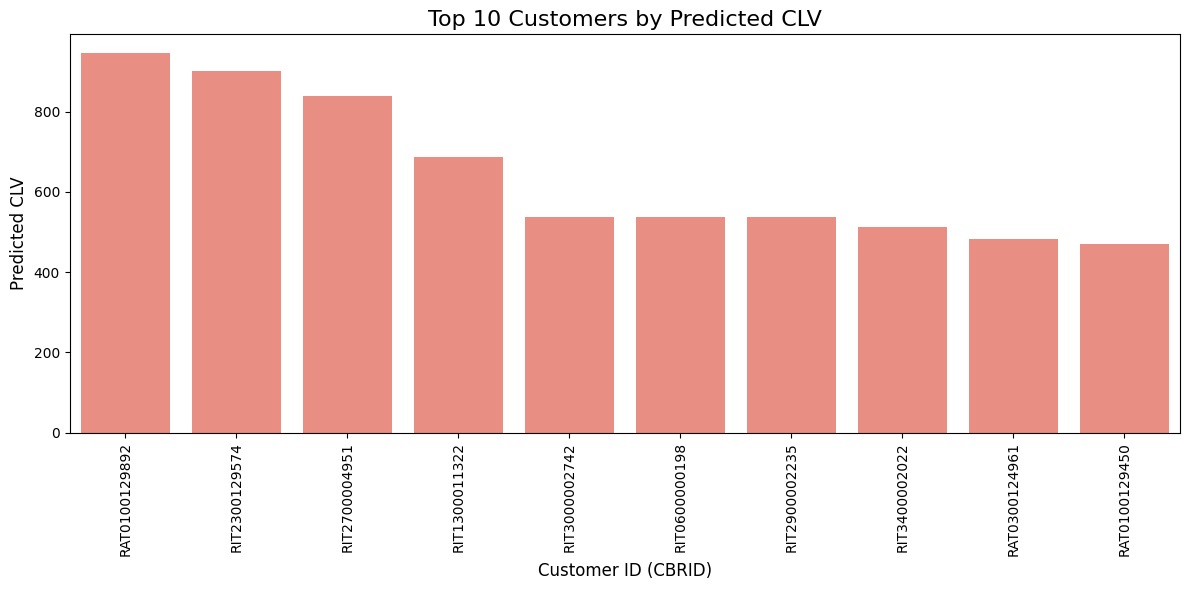

In [ ]:
# Reset the index to ensure 'CBRID' is a column
repeat_customers_reset = repeat_customers.reset_index()

# 1. Top 10 Customers according to CLV
top_10_customers_sorted = repeat_customers_reset.sort_values(by='CLV', ascending=False).head(10)

# Plot the Top 10 Customers by CLV
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_customers_sorted['CBRID'], y=top_10_customers_sorted['CLV'], color='salmon')
plt.title('Top 10 Customers by Predicted CLV', fontsize=16)
plt.xlabel('Customer ID (CBRID)', fontsize=12)
plt.ylabel('Predicted CLV', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Why Is Purchase-to-Monetary Value Ratio Important?**
   - The purchase-to-monetary value ratio highlights customers who are likely to make frequent purchases relative to their spending per transaction.
   - High ratios indicate customers who may not spend much per transaction but shop consistently, representing an opportunity to increase their transaction value.
   - This metric is critical for identifying customers who can be nurtured for higher profitability through strategies like upselling or bundling.

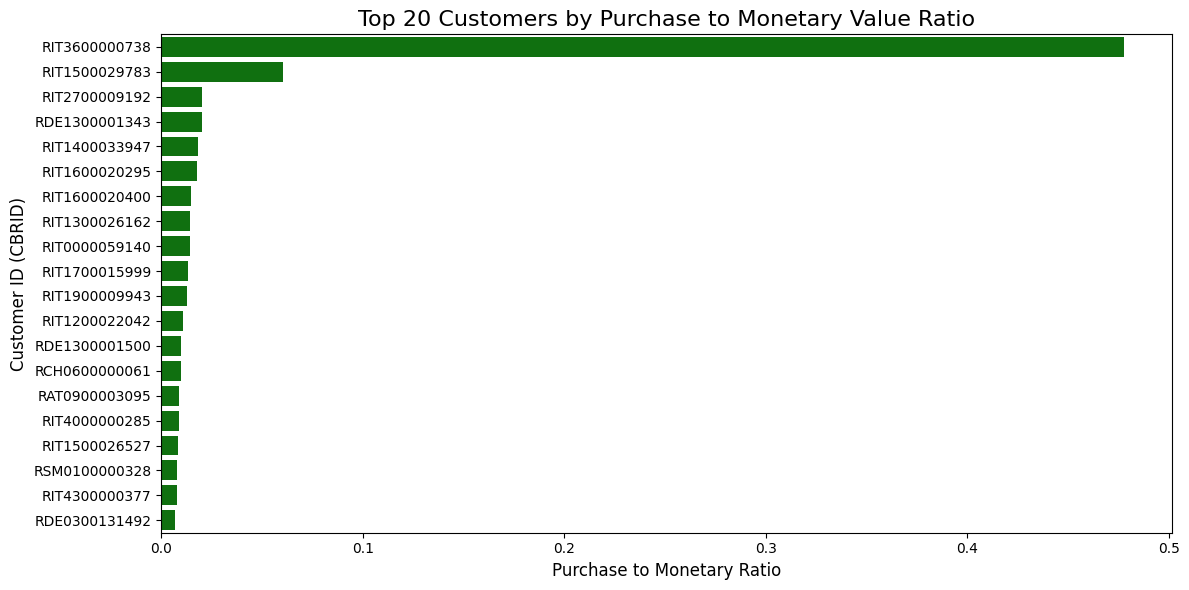

In [ ]:
# Step 1: Calculate the ratio of predicted_purchases to monetary_value
returning_customers_summary['purchase_to_monetary_ratio'] = returning_customers_summary['predicted_purchases'] / returning_customers_summary['monetary_value']

# Step 2: Reset index to ensure 'CBRID' is a column and not part of the index
returning_customers_summary_reset = returning_customers_summary.reset_index()

# Step 3: Get the top 20 customers with the highest purchase_to_monetary_ratio
top_20_ratio_customers = returning_customers_summary_reset.nlargest(20, 'purchase_to_monetary_ratio')

# Step 5: Create a horizontal bar plot to visualize the top 20 customers by purchase to monetary ratio
plt.figure(figsize=(12, 6))
sns.barplot(y=top_20_ratio_customers['CBRID'], x=top_20_ratio_customers['purchase_to_monetary_ratio'], color='green')

# Add title and labels
plt.title('Top 20 Customers by Purchase to Monetary Value Ratio', fontsize=16)
plt.xlabel('Purchase to Monetary Ratio', fontsize=12)
plt.ylabel('Customer ID (CBRID)', fontsize=12)
plt.tight_layout()
plt.show()

### Visualizing Customer Distribution by RFM Segments

In this section, we analyze the distribution of customers across different **RFM segments** based on their Recency, Frequency, and Monetary scores.

1. **Process:**
   - Used a count plot to visualize the number of customers in each RFM segment.
   - Customized the plot for clarity:
     - Adjusted figure size for better readability.
     - Rotated x-axis labels to prevent overlapping.

2. **Purpose of RFM Segments:**
   - RFM segments categorize customers based on their purchasing behavior.


GRAPH FOR DETERMINING WHICH PRODUCTS CONTRIBUTED TO CLV MORE

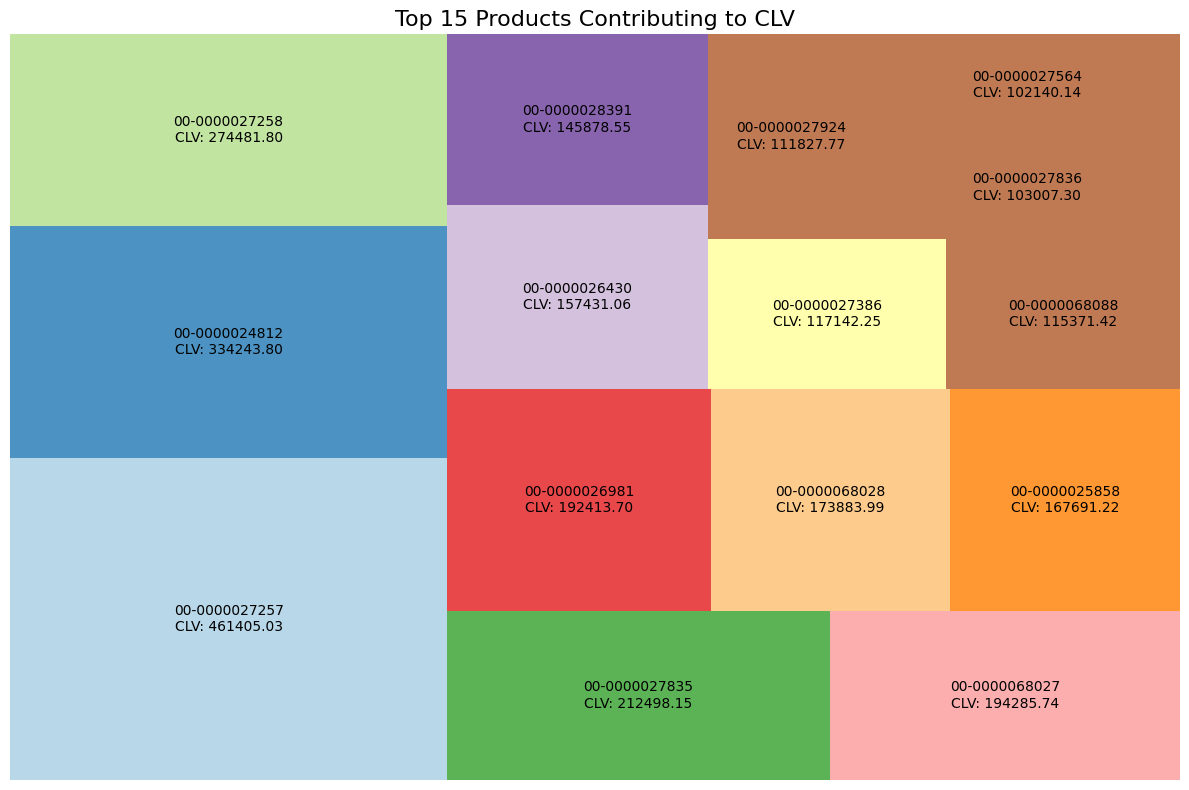

In [ ]:
# Step 1: Merge `repeat_customers` with `retail_df` to include `CODEARTICLE`
repeat_customers_with_products = repeat_customers.merge(
    retail_df[['CBRID', 'CODEARTICLE']],
    on='CBRID',
    how='left'
)

# Step 2: Aggregate CLV by Product
product_clv = repeat_customers_with_products.groupby('CODEARTICLE')['CLV'].sum().reset_index()
product_clv = product_clv.sort_values(by='CLV', ascending=False)

# Select top 15 products by CLV contribution
top_products_clv = product_clv.head(15)

# Step 3: Create the Treemap
plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=top_products_clv['CLV'],
    label=[f"{row['CODEARTICLE']}\nCLV: {row['CLV']:.2f}" for _, row in top_products_clv.iterrows()],
    color=plt.cm.Paired(range(len(top_products_clv))),  # Use paired colormap for variety
    alpha=0.8
)

# Add Title and Remove Axes
plt.title('Top 15 Products Contributing to CLV', fontsize=16)
plt.axis('off')  # Hide axes for a cleaner look
plt.tight_layout()
plt.show()


In [ ]:
!pip install Lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 10.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd


In [ ]:
retail_df.columns

Index(['DATE', 'TIME', 'STOREID', 'CODEARTICLE', 'EANCODE', 'RECEIPTNUMBER',
       'QUANTITY', 'CBRID', 'CURRENCYID', 'TOTALTAXINCLUDED',
       'ISGENERICCUSTOMER', 'OBERALPID'],
      dtype='object')

In [ ]:
retail = pd.read_parquet('/content/retail_20250114_2.parquet')

In [ ]:
# Ensure no NaN values in 'CODEARTICLE' before applying .str.startswith()
retail_df = retail[retail['CODEARTICLE'].fillna('').str.startswith("00-")].reset_index(drop=True)

# Display the filtered DataFrame structure to confirm
retail_df.head()


,DATE,TIME,STOREID,CODEARTICLE,EANCODE,RECEIPTNUMBER,QUANTITY,CBRID,CURRENCYID,TOTALTAXINCLUDED,ISGENERICCUSTOMER,OBERALPID
0,2024-11-30,15:31:30,AT01,00-0000025858,4053865477766,24003348,1,RAT0100132257,EUR,40.000,0,None
1,2024-11-30,15:28:14,AT01,00-0000028358,4053866446242,24003347,-1,RAT0100132257,EUR,-168.000,0,None
2,2024-11-30,15:28:14,AT01,00-0000028455,4053866573085,24003347,1,RAT0100132257,EUR,311.430,0,None
3,2024-11-30,15:28:14,AT01,00-0000028774,4053866585965,24003347,1,RAT0100132257,EUR,28.810,0,None
4,2024-11-30,15:28:14,AT01,00-0000028644,4053866539968,24003347,1,RAT0100132257,EUR,23.360,0,None


# Neural Network

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt


In [ ]:
# Step 1: Data Cleaning and Preparation
retail_df['DATE'] = pd.to_datetime(retail_df['DATE'])


In [ ]:
# Filter positive transactions and remove NaN
retail_df = retail_df[retail_df['TOTALTAXINCLUDED'] > 0].dropna()

In [ ]:
# Ensure the 'DATE' column is in datetime format
retail_df['DATE'] = pd.to_datetime(retail_df['DATE'])

# Calculate RFM metrics
rfm = retail_df.groupby('CBRID').agg(
    recency=('DATE', lambda x: (x.max() - x.min()).days),  # Difference between max and min dates
    frequency=('RECEIPTNUMBER', 'nunique'),  # Count of unique receipts
    monetary=('TOTALTAXINCLUDED', 'sum')     # Sum of monetary values
).reset_index()

# Display RFM metrics
print(rfm.head())


     CBRID  recency  frequency monetary
0  0000001      332          2  136.500
1      123        0          1   91.000
2   DE0107        0          1  200.000
3  GOLLING        0          1  122.500
4  R000001      153          4   88.000


In [ ]:
# Add normalized columns
rfm['recency_norm'] = rfm['recency'] / rfm['recency'].max()
rfm['frequency_norm'] = rfm['frequency'] / rfm['frequency'].max()
rfm['monetary_norm'] = rfm['monetary'] / rfm['monetary'].max()


In [ ]:
rfm.describe()

,recency,frequency,monetary,recency_norm,frequency_norm,clv,predicted_clv
count,280424.000000,280424.000000,280424.000000,280424.000000,280424.000000,280424.000000,280424.000000
mean,347.066214,2.388783,328.755958,0.100221,0.008411,394.507150,394.552338
std,661.887069,3.129628,485.826846,0.191131,0.011020,582.992216,583.176086
min,0.000000,1.000000,0.010000,0.000000,0.003521,0.012000,-0.029718
25%,0.000000,1.000000,104.000000,0.000000,0.003521,124.800000,124.716866
50%,0.000000,1.000000,193.000000,0.000000,0.003521,231.600000,231.808167
75%,369.000000,3.000000,376.400000,0.106555,0.010563,451.680000,451.741669
max,3463.000000,284.000000,44961.620000,1.000000,1.000000,53953.944000,54015.539062


In [ ]:
# Create the target variable CLV (simulated as monetary * 1.2 for next year)


# Ensure the 'monetary' column is in float format
rfm['monetary'] = rfm['monetary'].astype(float)

# Create the target variable CLV (simulated as monetary * 1.2 for next year)
rfm['clv'] = rfm['monetary'] * 1.2

# Display the updated dataframe
print(rfm.head())



     CBRID  recency  frequency  monetary  recency_norm  frequency_norm  \
0  0000001      332          2     136.5      0.095871        0.007042   
1      123        0          1      91.0      0.000000        0.003521   
2   DE0107        0          1     200.0      0.000000        0.003521   
3  GOLLING        0          1     122.5      0.000000        0.003521   
4  R000001      153          4      88.0      0.044181        0.014085   

                      monetary_norm    clv  
0  0.003035922638018825834122524945  163.8  
1  0.002023948425345883889415016630  109.2  
2  0.004448238297463481075637399186  240.0  
3  0.002724545957196382158827907002  147.0  
4  0.001957224850883931673280455642  105.6  


#### This formula estimates the customer lifetime value (CLV) for the next year by assuming it will be 20% higher than the total monetary value of their past transactions.

- The multiplication by 1.2 in the formula is a simple assumption to project growth or future spending, estimating that the customer's monetary value will increase by 20% in the next period.

- This factor is often used as a placeholder or rough estimate in scenarios where we expect slight growth in customer spending, but it can be adjusted based on real business data or trends.

In [ ]:
# Step 2: Split Data
X = rfm[['recency_norm', 'frequency_norm', 'monetary_norm']]
y = rfm['clv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Step 3: Build Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_dim=X_train.shape[1]),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [ ]:
# Step 4: Train the Model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=1)

Epoch 1/30
7011/7011 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.7682 - mae: 0.3831 - val_loss: 0.2325 - val_mae: 0.3272
Epoch 2/30
7011/7011 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.5358 - mae: 0.3504 - val_loss: 0.0022 - val_mae: 7.0871e-04
Epoch 3/30
7011/7011 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.4640 - mae: 0.2643 - val_loss: 0.0116 - val_mae: 0.0041
Epoch 4/30
7011/7011 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 2.4793 - mae: 0.3325 - val_loss: 0.0092 - val_mae: 0.0054
Epoch 5/30
7011/7011 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.3572 - mae: 0.2048 - val_loss: 0.0052 - val_mae: 0.0103
Epoch 6/30
7011/7011 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.5695 - mae: 0.3165 - val_loss: 0.0504 - val_mae: 0.1509
Epoch 7/30
7011/7011 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1.4201 - mae: 0.3367 - val_loss: 0.0114 - val_mae: 0.0096
Epoch 8/30
7011/7011 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.7713 - mae: 0.3199 - val_loss: 0.6006 - val_mae: 0.7592
Epoch 9/30
7011/7011 ━━━━━━━

In [ ]:
# Step 5: Evaluate the Model
y_pred = model.predict(X_test)
mape = np.mean(np.abs((y_test - y_pred.flatten()) / y_test)) * 100
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [ ]:
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Square Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Percentage Error (MAPE): 0.04%
Root Mean Square Error (RMSE): 0.38
R² Score: 1.00


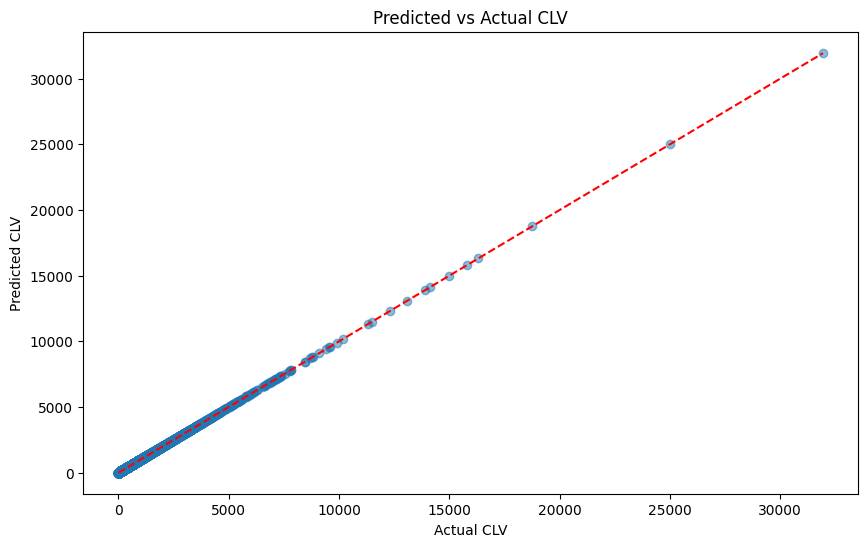

In [ ]:
# Step 6: Visualize Actual vs Predicted CLV
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred.flatten(), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')
plt.title('Predicted vs Actual CLV')
plt.show()

In [ ]:
# Step 7: Analyze Top Customers
rfm['predicted_clv'] = model.predict(X).flatten()
top_customers = rfm.sort_values(by='predicted_clv', ascending=False).head(10)
print("Top 10 Customers by Predicted CLV:")
print(top_customers[['CBRID', 'predicted_clv', 'clv']])


8764/8764 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
Top 10 Customers by Predicted CLV:
                CBRID  predicted_clv        clv
123870  RIT1300011322   54015.539062  53953.944
80172   RIT0600000198   42396.265625  42344.832
10408   RAT0100129892   38028.703125  37985.340
217051  RIT2300129574   31977.144531  31938.732
123170  RIT1300010564   25042.597656  25008.588
213267  RIT2300125610   21859.292969  21827.748
78            R000207   21381.882812  21349.320
5965    RAT0100124747   20907.927734  20876.760
12532   RAT0200009270   19941.093750  19910.580
1094          R002165   19892.419922  19861.320
